# Simulator Example

In [1]:
import matplotlib.pyplot as plt

In [2]:
cost_failure = 1200
cost_component = 100
cost_inspection = 100
cost_replacement = 1000

In [3]:
eta = 30*24
beta = 3

expiration = 1.1*eta

In [4]:
mu = 7*24
sigma = 0.15*mu

theta = 12

In [5]:
inspection_threshold = 0.5
inspection_deviation = 0.05

In [6]:
r=0.0005
nu=0.00005

### Simulate

We show an example of how to use the simulator implemented in the package `simmcm2d` to obtain samples. Do not forget to have the library in question installed in order to run the following.

In [7]:
from simmcm2d import sample_datasets, get_kpi, sample_to_table

In [8]:
param = {
    # component failure age parameters
    "eta":eta,
    "beta":beta,
    "expiration":expiration,
    # inspection quality and schedule
    "mu":mu,
    "sigma":sigma,
    "theta":theta,
    "inspection_deviation":inspection_deviation,
    "inspection_threshold":inspection_threshold,
    # population dynamic parameters
    "r": r,
    "nu": nu
}

costs = {
    "replacement":cost_replacement,
    "inspection":cost_inspection,
    "component":cost_component,
    "failure":cost_failure
}

In [10]:
df = sample_datasets(param, costs,
                     n_systems = 250,
                     date_first = "2010-01-01",
                     date_final = "2025-12-31 12:00",
                     id_0_component=0, id_0_system=0)

df.head()

,system_id,component_id,event_date,event_time,event_type,event_report,system_age,component_age,usage_since_last_event_h,FF,cost_event,cost_cumulated
0,1,1,2010-01-09,06:50:13,inspection,NaN,198.84,198.84,198.84,None,100,100
1,1,1,2010-01-16,00:16:27,inspection,NaN,360.27,360.27,161.44,None,100,200
2,1,1,2010-01-22,19:46:07,inspection,NaN,523.77,523.77,163.49,None,100,300
3,1,1,2010-01-26,01:48:49,failure,NaN,601.81,601.81,78.05,None,1200,1500
4,1,1,2010-01-26,01:48:49,replacement,unused,601.81,601.81,0.00,None,1100,2600


In [11]:
df.tail()

,system_id,component_id,event_date,event_time,event_type,event_report,system_age,component_age,usage_since_last_event_h,FF,cost_event,cost_cumulated
197972,100,38760,2025-12-31,09:10:30,replacement,unused,98581.16,161.61,0.00,None,1100,359300
197973,15,38684,2025-12-31,09:19:08,inspection,NaN,102814.62,329.55,183.20,None,100,388600
197974,165,38770,2025-12-31,09:52:58,inspection,NaN,96604.66,139.96,139.96,None,100,349700
197975,127,38772,2025-12-31,10:53:33,inspection,NaN,97663.24,134.58,134.58,None,100,354000
197976,256,38624,2025-12-31,10:56:54,inspection,NaN,3337.09,503.47,176.13,None,100,10800


In [12]:
df.describe()

,system_id,component_id,system_age,component_age,usage_since_last_event_h,cost_event,cost_cumulated
count,197977.000000,197977.000000,197977.000000,197977.000000,197977.000000,197977.000000,197977.000000
mean,124.927335,19317.914344,48685.121296,441.693652,123.150493,449.569900,177007.767569
std,72.949130,11160.678251,28358.462580,200.360501,71.811535,490.275406,103965.007993
min,1.000000,1.000000,102.210000,23.190000,0.000000,100.000000,100.000000
25%,62.000000,9671.000000,24134.010000,288.970000,59.490000,100.000000,87200.000000
50%,124.000000,19321.000000,48404.100000,451.040000,151.730000,100.000000,175800.000000
75%,187.000000,28977.000000,72945.910000,611.990000,175.510000,1100.000000,265500.000000
max,256.000000,38772.000000,140203.510000,997.720000,288.050000,1200.000000,515300.000000


### Computing KPI

The library also exposes the following functionality responsible for computing the KPIs

In [13]:
KPI = get_kpi(df, costs=costs)

KPI

{'Average of failure per month': np.float64(148.11560693641619),
 'Average of failure per trimestre': np.float64(400.375),
 'Average of failure per year': np.float64(1601.5),
 'Stability per month': np.float64(138.43535017082783),
 'Stability per trimestre': np.float64(416.4806510373466),
 'Stability per year': np.float64(1694.6739792164549),
 'Average of replacement per month': np.float64(215.06770833333334),
 'Average of replacement per trimestre': np.float64(645.203125),
 'Average of replacement per year': np.float64(2580.8125),
 'Preventive Effectiveness Ratio (PER)': np.float64(1.4520259733713186),
 'Précision du détecteur': 0.8,
 'Taux de détection (Rappel)': np.float64(0.29),
 'Average cost of one system': np.float64(347673.828125),
 'Standard Deviation': np.float64(49766.16594767099)}

### Saving to Outputs Files

One can call directly the function `sample_to_table`, responsible for saving the sample and relevant parameters to a table. One can also use the functionality `.to_csv` from pandas to save the generated dataset to a file. 

In [14]:
df.to_csv("sample_system_dataset_0.csv")

In [15]:
sample_to_table(df, output_table_filepath="sample_system_datatable.csv",
                param=param,
                costs=costs,
                n_systems=250,
                date_first = "2010-01-01",
                date_final = "2025-12-31 12:00",
                id_0_component=0,
                id_0_system=0,
                output_data_filepath="sample_system_dataset_0.csv")

Alternativelly, the function `sample_datasets` can include the fields:
 * `output_data_filepath` - used to save the dataframe generated
 * `output_table_filepath` - used to save/reunite the parameters used

then the filepaths speficied are used to save the relevant data

In [16]:
df = sample_datasets(param, costs,
                     n_systems = 100,
                     date_first = "2010-01-01",
                     date_final = "2025-12-31 12:00",
                     id_0_component=0, id_0_system=0,
                     # filepaths
                     output_data_filepath="sample_system_dataset_1.csv",
                     output_table_filepath="sample_system_datatable.csv")

df.head()

,system_id,component_id,event_date,event_time,event_type,event_report,system_age,component_age,usage_since_last_event_h,FF,cost_event,cost_cumulated
0,1,1,2010-01-08,20:35:21,inspection,NaN,188.59,188.59,188.59,None,100,100
1,1,1,2010-01-15,15:12:59,inspection,NaN,351.22,351.22,162.63,None,100,200
2,1,1,2010-01-21,21:12:00,inspection,NaN,501.20,501.20,149.98,None,100,300
3,1,1,2010-01-23,15:20:16,failure,NaN,543.34,543.34,42.14,None,1200,1500
4,1,1,2010-01-23,15:20:16,replacement,unused,543.34,543.34,0.00,None,1100,2600


### Observe the distribution of fail ages

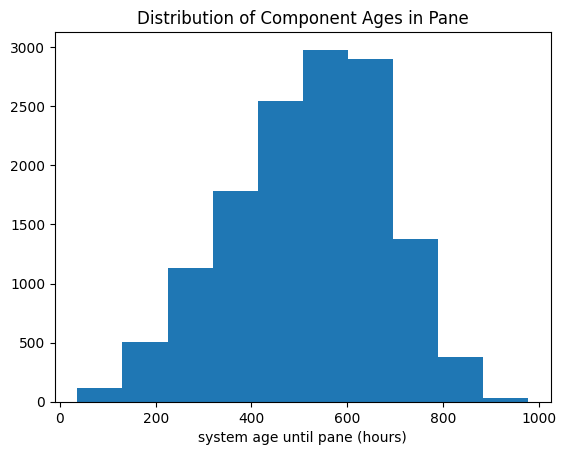

In [17]:
plt.hist(df[df.event_type=="failure"].component_age)
plt.xlabel("system age until pane (hours)")
plt.title("Distribution of Component Ages in Pane")
plt.show()

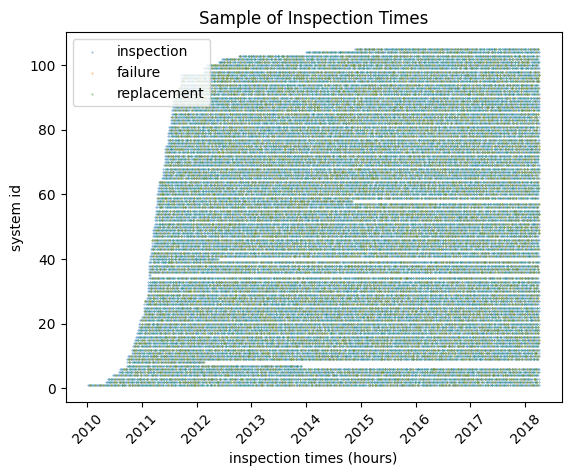

In [18]:
n_events_show = 50000
for e_type in df.event_type.unique():
    df_ = df[:n_events_show]
    df_ = df_[df_.event_type == e_type]
    plt.scatter(df_.event_date,
                df_.system_id,
                label=e_type,
                alpha=0.8, s=0.1)

plt.legend()
plt.xlabel("inspection times (hours)")
plt.ylabel("system id")
plt.xticks(rotation=45)
plt.title("Sample of Inspection Times")
plt.show()